<a href="https://colab.research.google.com/github/MahinourAbdelgawad/Plant-Disease-Detection/blob/main/2_species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Species and Disease Detection
## GOAL 2: Species Detection

In [2]:
# FOR RUNNING LOCALLY
! pip install matplotlib opencv-python numpy seaborn pandas tqdm scikit-learn kagglehub scikit-image


### STEP 0: Load dataset, examine data, and preprocess

In [3]:
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import time
import json

In [22]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [5]:
#LOCAL VERSION
! pip install python-dotenv
import os
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get('KAGGLE_API_TOKEN'):
    print("Error: Could not find 'KAGGLE_API_TOKEN'")

In [6]:
! pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("riteshmaurya86/cleaned-plant-disease-image-dataset")

print("Dataset downloaded to:", path)

100%|██████████| 1.34G/1.34G [01:05<00:00, 21.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/riteshmaurya86/cleaned-plant-disease-image-dataset/versions/1


In [23]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/PlantDetection'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# LOCAL VERSION
import os
OUTPUT_DIR = os.path.expanduser('outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
# we only need this to get the class folder names
DATA_DIR = os.path.join(path, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'valid')
TEST_DIR = os.path.join(DATA_DIR, 'test')

classes = sorted(os.listdir(TRAIN_DIR))
valid_classes = sorted(os.listdir(VALID_DIR))
print(f"Number of classes: {len(classes)}")

Number of classes: 38


## STEP 1: Classical ML
#### First: Prep data
Features were already extractred and saved from part 1

In [10]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [11]:
FEATURES_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features.npz')
VALID_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features_valid.npz')
TEST_PATH = os.path.join(OUTPUT_DIR, 'classical_ml_features_test.npz')

train_data = np.load(FEATURES_PATH, allow_pickle=True)
X_train, meta_train = train_data['X'], train_data['meta']

valid_data = np.load(VALID_PATH, allow_pickle=True)
X_valid, meta_valid = valid_data['X'], valid_data['meta']

test_data = np.load(TEST_PATH, allow_pickle=True)
X_test, meta_test = test_data['X'], test_data['meta']

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/classical_ml_features.npz'

In [16]:
#extract species from label
def get_species(class_name):
    #Species is the part before ___
    return class_name.split("___")[0]

SPECIES_LIST = sorted({get_species(c) for c in classes})
print(f"{len(SPECIES_LIST)} species: {SPECIES_LIST}")

SPECIES_KEYWORDS = {
    "Apple": "Apple", "Blueberry": "Blueberry", "Cherry_(including_sour)": "Cherry",
    "Corn_(maize)": "Corn", "Grape": "Grape", "Orange": "Orange", "Peach": "Peach",
    "Pepper,_bell": "Pepper", "Potato": "Potato", "Raspberry": "Raspberry",
    "Soybean": "Soybean", "Squash": "Squash", "Strawberry": "Strawberry", "Tomato": "Tomato",
}

#for the flat test folder
def get_species_from_filename(filename):
    for species, keyword in SPECIES_KEYWORDS.items():
        if keyword.lower() in filename.lower():
            return species
    return None

14 species: ['Apple', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']


In [ ]:
y_train_species = np.array([get_species(m.split('/')[0]) for m in meta_train])

y_valid_species = np.array([get_species(m.split('/')[0]) for m in meta_valid])


y_test_species = np.array([get_species_from_filename(m) for m in meta_test])

print(pd.Series(y_train_species).value_counts())

Tomato                     18345
Apple                       7771
Corn_(maize)                7316
Grape                       7222
Potato                      5702
Pepper,_bell                3901
Strawberry                  3598
Peach                       3566
Cherry_(including_sour)     3509
Soybean                     2021
Orange                      2010
Blueberry                   1816
Raspberry                   1781
Squash                      1736
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

#### Second: TRAIN!

In [ ]:
species_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    # svm skipped as it doesnt scale well?
}

species_results = {}
for name, model in species_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train_species)
    preds = model.predict(X_valid_scaled)
    elapsed = time.time() - start

    acc = accuracy_score(y_valid_species, preds)
    f1 = f1_score(y_valid_species, preds, average='macro')

    species_results[name] = {'model': model, 'acc': acc, 'f1': f1, 'time': elapsed}
    print(f"{name}: acc={acc:.3f}, f1_macro={f1:.3f}, time={elapsed:.1f}s")

best_species_name = max(species_results, key=lambda n: species_results[n]['f1'])
best_species_model = species_results[best_species_name]['model']
print(f"\nBest species model: {best_species_name}")

Logistic Regression: acc=0.739, f1_macro=0.767, time=72.2s
KNN: acc=0.897, f1_macro=0.890, time=7.3s
Random Forest: acc=0.946, f1_macro=0.943, time=77.7s
Hist Gradient Boosting: acc=0.960, f1_macro=0.958, time=42.7s

Best species model: Hist Gradient Boosting


#### Finally: Test best model on test data

Final test results for Hist Gradient Boosting:

              precision    recall  f1-score   support

       Apple       1.00      0.86      0.92         7
Corn_(maize)       1.00      1.00      1.00         3
      Potato       1.00      0.86      0.92         7
      Tomato       0.89      1.00      0.94        16

    accuracy                           0.94        33
   macro avg       0.97      0.93      0.95        33
weighted avg       0.95      0.94      0.94        33



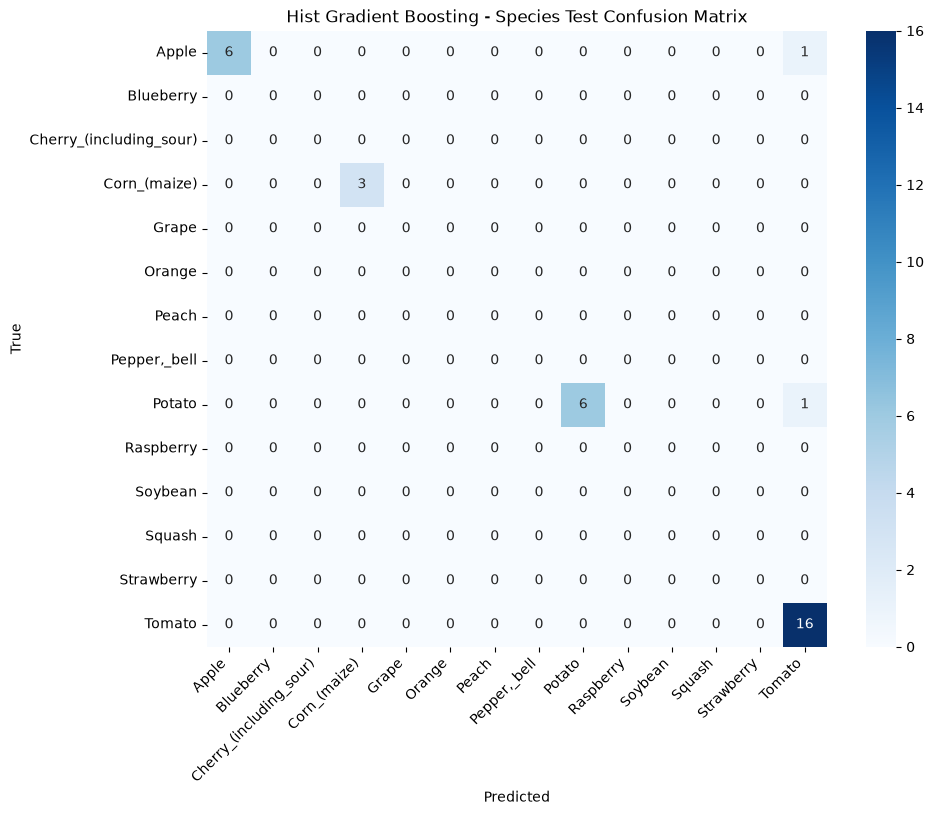

In [ ]:
final_preds = best_species_model.predict(X_test_scaled)
print(f"Final test results for {best_species_name}:\n")
print(classification_report(y_test_species, final_preds))

cm = confusion_matrix(y_test_species, final_preds, labels=SPECIES_LIST)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SPECIES_LIST, yticklabels=SPECIES_LIST)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'{best_species_name} - Species Test Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
report = classification_report(y_test_species, final_preds, output_dict=True)
with open(os.path.join(OUTPUT_DIR, 'classical_ml_species_summary.json'), 'w') as f:
    json.dump({
        "best_model": best_species_name,
        "comparison": {n: {"acc": r["acc"], "f1_macro": r["f1"]} for n, r in species_results.items()},
        "test_report": report,
    }, f, indent=2)
print(f"Saved species classification summary to {OUTPUT_DIR}")

Saved species classification summary to outputs


## STEP 2: DEEP LEARNING

#### First: Setup

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from collections import Counter

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cpu":
    print("WARNING: no GPU detected")

Using device: cuda


In [13]:
class LeafFolderDataset(Dataset):
    def __init__(self, root_dir, class_list, label_fn, label_to_idx, transform=None):
        self.transform = transform
        self.samples = []

        for c in class_list:
            label = label_to_idx[label_fn(c)]
            class_dir = os.path.join(root_dir, c)
            for fname in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


class LeafFlatDataset(Dataset):
    def __init__(self, root_dir, label_fn, label_to_idx, transform=None):
        self.filenames = os.listdir(root_dir)
        self.root_dir = root_dir
        self.label_fn = label_fn
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        path = os.path.join(self.root_dir, fname)
        label = self.label_to_idx[self.label_fn(fname)]
        img = Image.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img, label

In [14]:
IMG_SIZE_DL = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE_DL, IMG_SIZE_DL)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE_DL, IMG_SIZE_DL)),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std),
])

#### Second: Prep data and models

In [17]:
SPECIES_TO_IDX = {s: i for i, s in enumerate(SPECIES_LIST)}
IDX_TO_SPECIES = {i: s for s, i in SPECIES_TO_IDX.items()}

BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset_dl = LeafFolderDataset(TRAIN_DIR, classes, get_species, SPECIES_TO_IDX, transform=train_transform)
valid_dataset_dl = LeafFolderDataset(VALID_DIR, valid_classes, get_species, SPECIES_TO_IDX, transform=eval_transform)

train_loader = DataLoader(train_dataset_dl, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset_dl, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train samples: {len(train_dataset_dl)}, Valid samples: {len(valid_dataset_dl)}")

Train samples: 70295, Valid samples: 17572


In [18]:
# note that theres an imbalance between species
label_counts = Counter([l for _, l in train_dataset_dl.samples])
total = sum(label_counts.values())
num_classes = len(SPECIES_LIST)

class_weights = torch.tensor(
    [total / (num_classes * label_counts[i]) for i in range(num_classes)],
    dtype=torch.float32
).to(device)

In [19]:
def _get_head(model, arch_name):
    if arch_name == "mobilenet_v2":
        return model.classifier[-1]
    elif arch_name == "resnet50":
        return model.fc

def build_model(arch_name, num_classes):
    if arch_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    elif arch_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unknown architecture: {arch_name}")

    for param in model.parameters():
        param.requires_grad = False
    for param in _get_head(model, arch_name).parameters():
        param.requires_grad = True

    return model.to(device)

def set_backbone_trainable(model, trainable=True):
    for param in model.parameters():
        param.requires_grad = trainable

#### Third: TRAIN!

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1


def train_model(arch_name, num_classes, head_epochs=2, finetune_epochs=3, head_lr=1e-3, finetune_lr=1e-5):
    print(f"\n=== Training {arch_name} ===")
    model = build_model(arch_name, num_classes)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    history = []

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=head_lr)
    for epoch in range(head_epochs):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, valid_loader, criterion)
        print(f"[head {epoch+1}/{head_epochs}] train_loss={train_loss:.3f} val_acc={val_acc:.3f} val_f1={val_f1:.3f}")
        history.append({"stage": "head", "epoch": epoch+1, "val_acc": val_acc, "val_f1": val_f1})

    set_backbone_trainable(model, True)
    optimizer = torch.optim.Adam(model.parameters(), lr=finetune_lr)
    for epoch in range(finetune_epochs):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, valid_loader, criterion)
        print(f"[finetune {epoch+1}/{finetune_epochs}] train_loss={train_loss:.3f} val_acc={val_acc:.3f} val_f1={val_f1:.3f}")
        history.append({"stage": "finetune", "epoch": epoch+1, "val_acc": val_acc, "val_f1": val_f1})

    return model, history

In [ ]:
dl_species_results = {}

for arch in ["mobilenet_v2", "resnet50"]:
    start = time.time()
    model, history = train_model(arch, num_classes=len(SPECIES_LIST))
    elapsed = time.time() - start

    dl_species_results[arch] = {
        "model": model, "history": history,
        "val_acc": history[-1]["val_acc"], "val_f1": history[-1]["val_f1"],
        "train_time_sec": elapsed,
    }
    print(f"{arch}: val_acc={history[-1]['val_acc']:.3f}, val_f1={history[-1]['val_f1']:.3f}, time={elapsed/60:.1f} min")

comparison_df_species = pd.DataFrame({
    arch: {"val_acc": r["val_acc"], "val_f1": r["val_f1"], "train_time_min": r["train_time_sec"]/60}
    for arch, r in dl_species_results.items()
}).T
print(comparison_df_species)

best_dl_species_name = comparison_df_species["val_f1"].idxmax()
best_dl_species_model = dl_species_results[best_dl_species_name]["model"]

#### Finally: Test on the best model

In [29]:
best_dl_species_name = summary['best_model']

best_dl_species_model = build_model(best_dl_species_name, num_classes=len(SPECIES_LIST))
best_dl_species_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'best_dl_species_model_{best_dl_species_name}.pt')))
best_dl_species_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

test: 100%|██████████| 2/2 [00:00<00:00,  3.96it/s]


              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         7
Corn_(maize)       1.00      1.00      1.00         3
      Potato       1.00      1.00      1.00         7
      Tomato       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



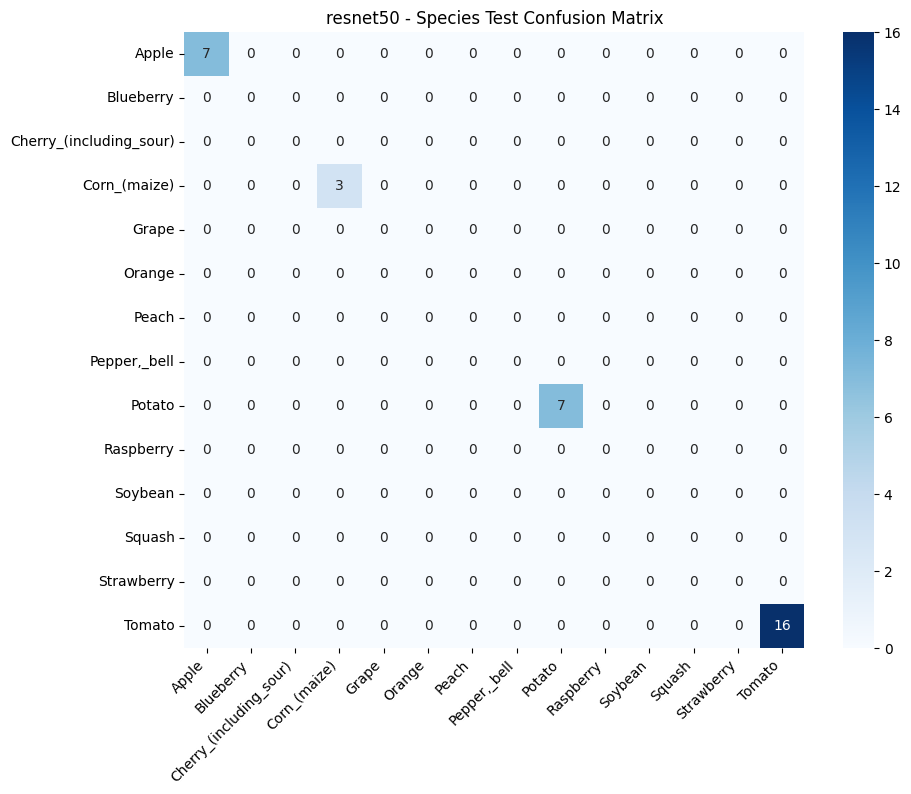

NameError: name 'comparison_df_species' is not defined

In [30]:
TEST_IMAGES_DIR = os.path.join(TEST_DIR, 'images')
test_dataset_dl = LeafFlatDataset(TEST_IMAGES_DIR, get_species_from_filename, SPECIES_TO_IDX, transform=eval_transform)
test_loader = DataLoader(test_dataset_dl, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

best_dl_species_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="test"):
        outputs = best_dl_species_model(imgs.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

pred_species = [IDX_TO_SPECIES[p] for p in all_preds]
true_species = [IDX_TO_SPECIES[l] for l in all_labels]

print(classification_report(true_species, pred_species))

cm = confusion_matrix(true_species, pred_species, labels=SPECIES_LIST)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SPECIES_LIST, yticklabels=SPECIES_LIST)
plt.xticks(rotation=45, ha='right')
plt.title(f'{best_dl_species_name} - Species Test Confusion Matrix')
plt.show()

report = classification_report(true_species, pred_species, output_dict=True)
with open(os.path.join(OUTPUT_DIR, 'dl_species_summary.json'), 'w') as f:
    json.dump({"best_model": best_dl_species_name,
                "comparison": comparison_df_species.to_dict(orient="index"),
                "test_report": report}, f, indent=2)
torch.save(best_dl_species_model.state_dict(), os.path.join(OUTPUT_DIR, f'best_dl_species_model_{best_dl_species_name}.pt'))

test: 100%|██████████| 2/2 [00:00<00:00,  5.64it/s]


              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         7
Corn_(maize)       1.00      1.00      1.00         3
      Potato       1.00      1.00      1.00         7
      Tomato       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



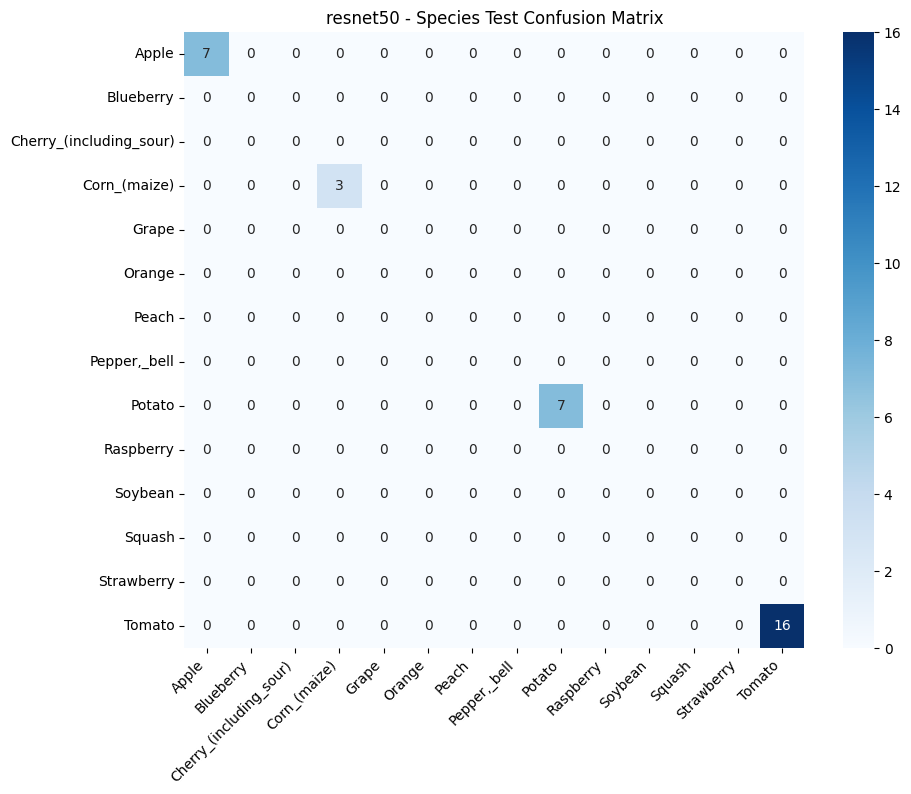

In [31]:
TEST_IMAGES_DIR = os.path.join(TEST_DIR, 'images')
test_dataset_dl = LeafFlatDataset(TEST_IMAGES_DIR, get_species_from_filename, SPECIES_TO_IDX, transform=eval_transform)
test_loader = DataLoader(test_dataset_dl, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

best_dl_species_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="test"):
        outputs = best_dl_species_model(imgs.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

pred_species = [IDX_TO_SPECIES[p] for p in all_preds]
true_species = [IDX_TO_SPECIES[l] for l in all_labels]

print(classification_report(true_species, pred_species))

cm = confusion_matrix(true_species, pred_species, labels=SPECIES_LIST)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SPECIES_LIST, yticklabels=SPECIES_LIST)
plt.xticks(rotation=45, ha='right')
plt.title(f'{best_dl_species_name} - Species Test Confusion Matrix')
plt.show()

In [24]:
import json
with open(os.path.join(OUTPUT_DIR, 'dl_species_summary.json')) as f:
    summary = json.load(f)

print(f"Best model: {summary['best_model']}\n")
print(pd.DataFrame(summary['comparison']).T)
print()
print(pd.DataFrame(summary['test_report']).T)

Best model: resnet50

               val_acc    val_f1  train_time_min
mobilenet_v2  0.995903  0.996283       30.588138
resnet50      0.998520  0.998704       55.842607

              precision  recall  f1-score  support
Apple               1.0     1.0       1.0      7.0
Corn_(maize)        1.0     1.0       1.0      3.0
Potato              1.0     1.0       1.0      7.0
Tomato              1.0     1.0       1.0     16.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     33.0
weighted avg        1.0     1.0       1.0     33.0
